In [3]:
import pandas as pd
import zipfile
import os

inner_zip_path = 'UCI HAR Dataset.zip' 

extract_dir = 'extracted_files'

with zipfile.ZipFile(inner_zip_path, 'r') as z_inner:
    file_names = z_inner.namelist()
    for file in file_names:
        if file.endswith('.txt'):  
            z_inner.extract(file, path=extract_dir)

features_path = os.path.join(extract_dir, 'UCI HAR Dataset', 'features.txt')
train_data_path = os.path.join(extract_dir, 'UCI HAR Dataset', 'train', 'X_train.txt')
train_labels_path = os.path.join(extract_dir, 'UCI HAR Dataset', 'train', 'y_train.txt')
train_subject_path = os.path.join(extract_dir, 'UCI HAR Dataset', 'train', 'subject_train.txt')
test_data_path = os.path.join(extract_dir, 'UCI HAR Dataset', 'test', 'X_test.txt')
test_labels_path = os.path.join(extract_dir, 'UCI HAR Dataset', 'test', 'y_test.txt')
test_subject_path = os.path.join(extract_dir, 'UCI HAR Dataset', 'test', 'subject_test.txt')

features = pd.read_csv(features_path, delim_whitespace=True, header=None, usecols=[1])
feature_names = features.iloc[:, 0].tolist()

from collections import Counter
counts = Counter(feature_names)
for i, item in enumerate(feature_names):
    if counts[item] > 1:
        feature_names[i] = feature_names[i] + '_' + str(counts[item])
        counts[item] -= 1

train_data = pd.read_csv(train_data_path, delim_whitespace=True, header=None, names=feature_names)
train_labels = pd.read_csv(train_labels_path, delim_whitespace=True, header=None, names=['Activity'])
train_subjects = pd.read_csv(train_subject_path, delim_whitespace=True, header=None, names=['Subject'])

test_data = pd.read_csv(test_data_path, delim_whitespace=True, header=None, names=feature_names)
test_labels = pd.read_csv(test_labels_path, delim_whitespace=True, header=None, names=['Activity'])
test_subjects = pd.read_csv(test_subject_path, delim_whitespace=True, header=None, names=['Subject'])

train = pd.concat([train_subjects, train_labels, train_data], axis=1)
test = pd.concat([test_subjects, test_labels, test_data], axis=1)

HARdata = pd.concat([train, test], axis=0).reset_index(drop=True)

HARdata.head()

/var/folders/z4/nqbbpnv52gddff6vt_dtcgvm0000gn/T/ipykernel_3549/4258109148.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  features = pd.read_csv(features_path, delim_whitespace=True, header=None, usecols=[1])
/var/folders/z4/nqbbpnv52gddff6vt_dtcgvm0000gn/T/ipykernel_3549/4258109148.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  train_data = pd.read_csv(train_data_path, delim_whitespace=True, header=None, names=feature_names)
/var/folders/z4/nqbbpnv52gddff6vt_dtcgvm0000gn/T/ipykernel_3549/4258109148.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  train_labels = pd.read_csv(train_labels_path, delim_whitespace=True, header=None, names=['Activity'])
/var/folders/z4/nqbbpnv52gddff6vt_

,Subject,Activity,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,5,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


### PCA

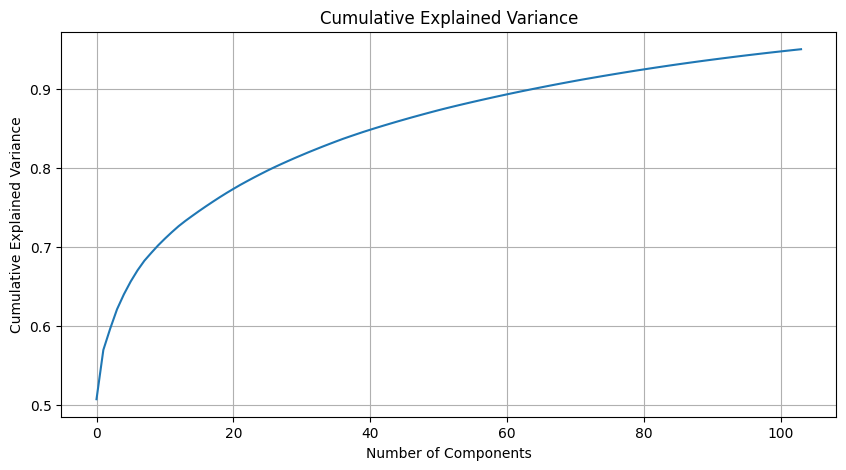

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

features = HARdata.drop(['Subject', 'Activity'], axis=1)

scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)

pca = PCA(n_components=0.95)  
principal_components = pca.fit_transform(features_standardized)

columns = ['PC' + str(i+1) for i in range(pca.n_components_)]
principal_df = pd.DataFrame(data=principal_components, columns=columns)

pca_df = pd.concat([HARdata[['Subject', 'Activity']], principal_df], axis=1)


plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [5]:
print("Cumulative Explained Variance Ratio:")
print(np.cumsum(pca.explained_variance_ratio_))

Cumulative Explained Variance Ratio:
[0.50738221 0.56977407 0.59669971 0.62122842 0.64011777 0.65643173
 0.67057706 0.68273917 0.69259164 0.70208392 0.71066696 0.71876676
 0.72642539 0.73319206 0.73949448 0.74565165 0.751605   0.75737696
 0.76301127 0.76841957 0.77360785 0.77863527 0.78336756 0.78800575
 0.79247423 0.79687291 0.80104154 0.80504963 0.80894035 0.81275373
 0.81642243 0.82006601 0.82355825 0.82702561 0.830381   0.83367511
 0.83691335 0.83991843 0.84286097 0.84576549 0.84852314 0.85122179
 0.85386374 0.85644405 0.85899435 0.86147211 0.86392749 0.86631039
 0.86866941 0.87098985 0.87327345 0.87546527 0.87759158 0.87968303
 0.88171782 0.88372949 0.8857106  0.88765451 0.8895796  0.89147499
 0.89333902 0.89516825 0.89697782 0.89874146 0.90048333 0.90219804
 0.90390845 0.90558298 0.90722001 0.90883447 0.9104374  0.9120033
 0.91350564 0.91499366 0.91647968 0.91792957 0.91937372 0.92079514
 0.92220344 0.92357467 0.92490816 0.92623684 0.92754834 0.92883283
 0.93010695 0.93135118 0.9

In [6]:
pca_df.head()

,Subject,Activity,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102,PC103,PC104
0,1,5,-16.380980,1.995083,3.415690,0.649858,-7.825062,-2.771964,-2.298285,-5.227723,...,-0.453863,-0.952478,-0.643372,-2.644553,-1.672523,0.094326,-1.669191,0.045822,-2.044934,-1.053981
1,1,5,-15.582173,1.182594,-0.321207,-2.748083,-4.729536,-1.588823,0.334051,-1.621178,...,-0.617054,1.197205,0.157327,-0.182153,0.443352,-0.900287,-1.290595,-0.236736,0.302279,-0.503428
2,1,5,-15.423989,2.243166,-1.237784,-4.002881,-4.402735,-1.035089,0.129769,-1.279185,...,0.166897,-0.727894,0.067191,0.109415,0.018823,-1.166463,0.714439,0.637714,-0.284283,0.484183
3,1,5,-15.647807,3.762882,-1.275283,-2.806663,-3.239111,-0.743524,-0.326070,-1.742983,...,0.757726,-0.215954,0.237352,-1.008373,-0.043515,-0.563716,0.776140,-0.700228,-0.445514,0.241850
4,1,5,-15.842320,4.438897,-1.808232,-3.160507,-3.331172,-0.911551,0.861931,-0.090126,...,-0.186292,0.278911,0.541911,-0.024492,-0.425371,0.207763,0.014403,-0.229281,0.432271,0.429974


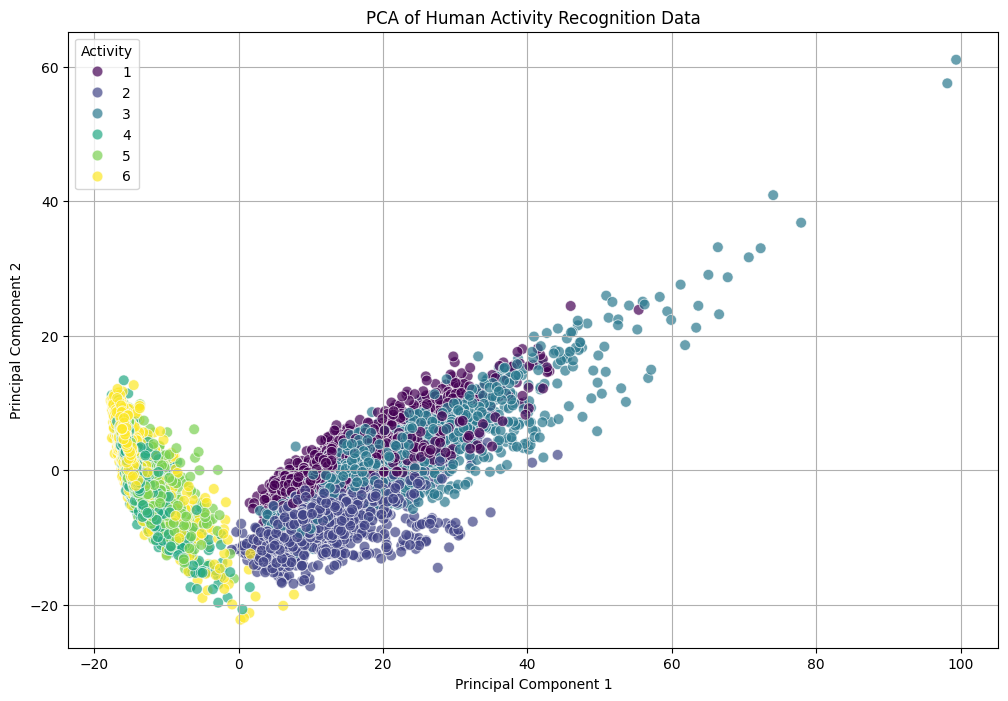

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = pca_df[['PC1', 'PC2', 'Activity']]

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x='PC1', y='PC2', hue='Activity', data=plot_data, palette='viridis', s=60, alpha=0.7)
plt.title('PCA of Human Activity Recognition Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Activity', loc='best')
plt.grid(True)
plt.show()

Conclusions: There is distinct clustering with overlapping activities. Principal component 1 captures majority of variance and PC 2 shows the variance but to a lesser extent. 

### K-Means Clustering

In [41]:
from sklearn.cluster import KMeans

k = 6  

kmeans = KMeans(n_clusters=k, random_state=42)
pca_df['Cluster'] = kmeans.fit_predict(pca_df[['PC1', 'PC2']])

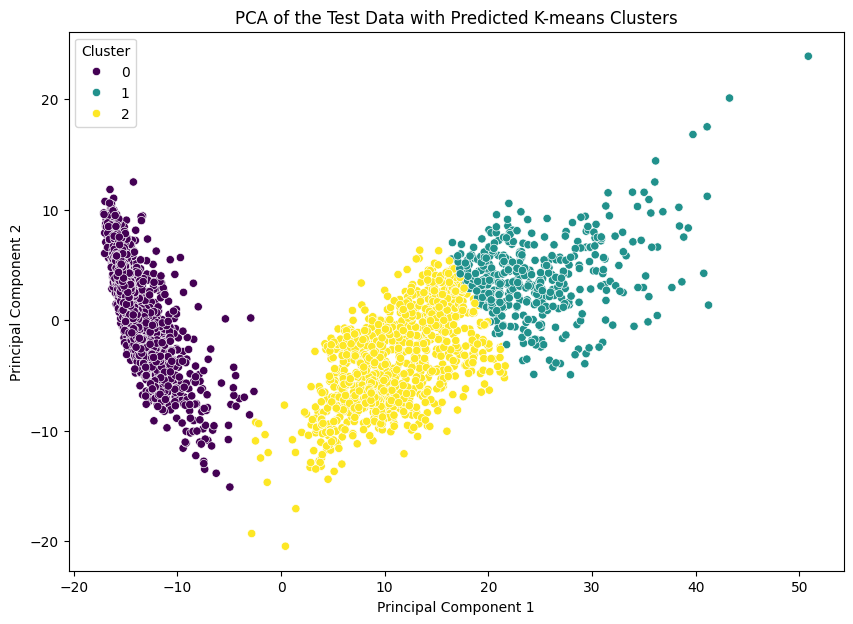

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you have `test_pca_df` with 'PC1', 'PC2', and 'Cluster'

# Plot the PCA graph with clusters for the test data
plt.figure(figsize=(10, 7))
sns.scatterplot(data=test_pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('PCA of the Test Data with Predicted K-means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


### T-SNE

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 10299 samples in 0.000s...
[t-SNE] Computed neighbors for 10299 samples in 0.206s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10299
[t-SNE] Computed conditional probabilities for sample 2000 / 10299
[t-SNE] Computed conditional probabilities for sample 3000 / 10299
[t-SNE] Computed conditional probabilities for sample 4000 / 10299
[t-SNE] Computed conditional probabilities for sample 5000 / 10299
[t-SNE] Computed conditional probabilities for sample 6000 / 10299
[t-SNE] Computed conditional probabilities for sample 7000 / 10299
[t-SNE] Computed conditional probabilities for sample 8000 / 10299
[t-SNE] Computed conditional probabilities for sample 9000 / 10299
[t-SNE] Computed conditional probabilities for sample 10000 / 10299
[t-SNE] Computed conditional probabilities for sample 10299 / 10299
[t-SNE] Mean sigma: 4.259575
[t-SNE] KL divergence after 250 iterations with early exaggeration: 80.986893
[t-SNE] KL

/var/folders/z4/nqbbpnv52gddff6vt_dtcgvm0000gn/T/ipykernel_3549/3015872846.py:14: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(


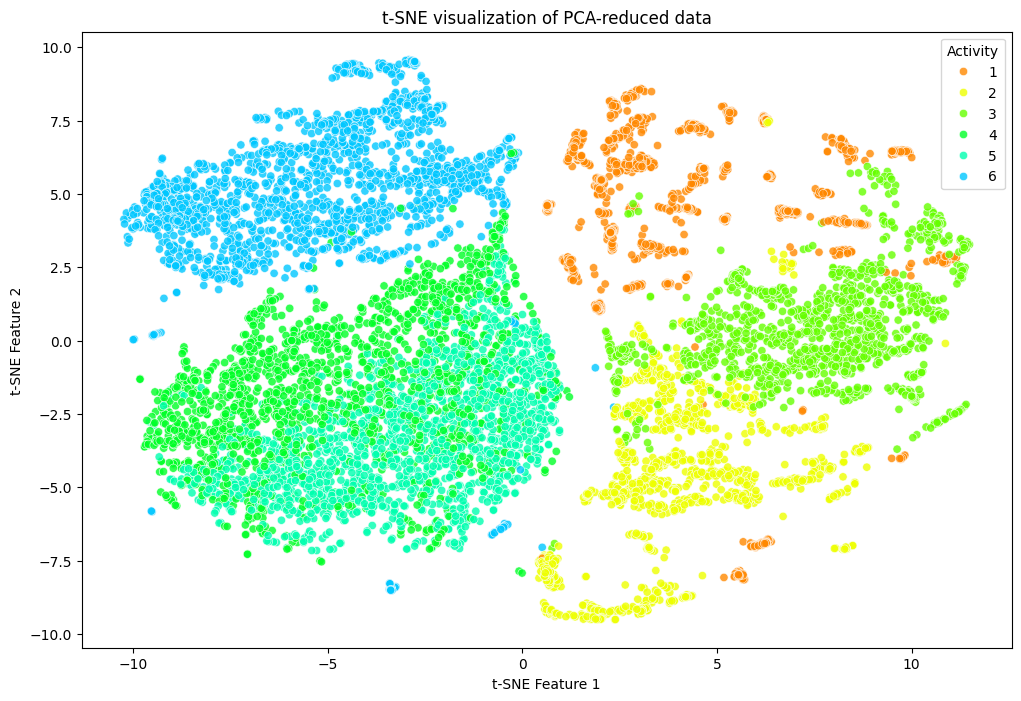

In [10]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(principal_df)

tsne_df = pd.DataFrame(data={
    'TSNE1': tsne_results[:,0],
    'TSNE2': tsne_results[:,1],
    'Activity': HARdata['Activity']
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="TSNE1", y="TSNE2",
    hue="Activity",
    palette=sns.color_palette("hsv", 10),
    data=tsne_df,
    legend="full",
    alpha=0.8
)
plt.title('t-SNE visualization of PCA-reduced data')
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.show()

compare the jaccard score with k-mean and cluster - pick one/ two 

Pick one subject - one plot for each activity, look at the time series and k-means after PCA, what seperate the different for static and what common similarity

The subject is for inertial signal

As I change the number of components that I feed to k-means, how does that affect my classification accuracy?
- still prediction 
train/X_train.txt -> PCA -> select top-n components -> k-means

time series for a particuplar subject, get a sense about how are they smilar? are we losing information with mean? - try the box graph with sandard deviation. 
- train/Inertial Signals -> looking at standing, sitting, and lying down -> plot some example time series (for a particular subject)
- Have a clean final code
- K-mean and clustering for the time series

## Logistic Regression

On hold. 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


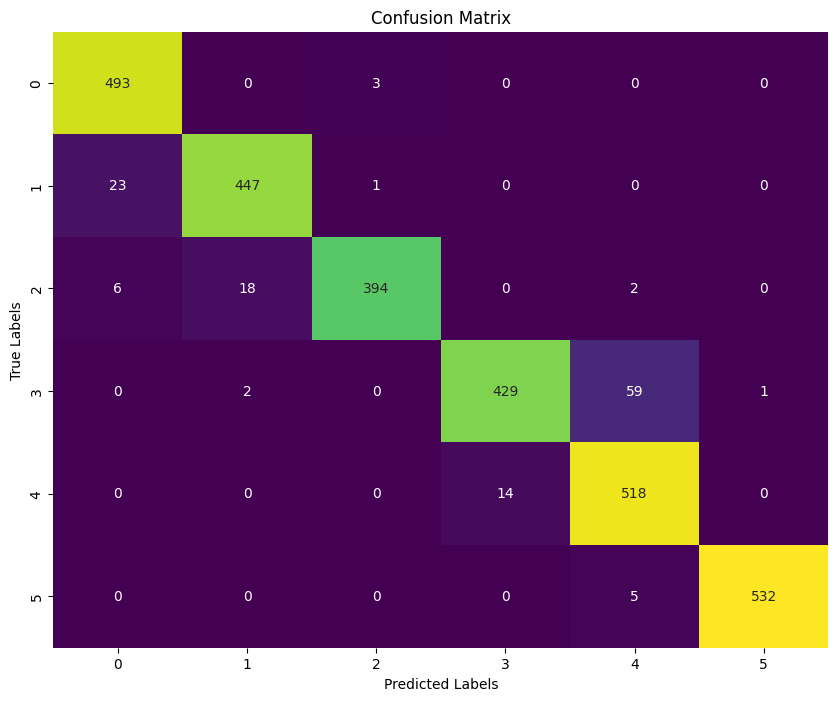

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data)
X_test_scaled = scaler.transform(test_data)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, train_labels)

y_pred = log_reg.predict(X_test_scaled)

class_report = classification_report(test_labels, y_pred, output_dict=True)
class_report_df = pd.DataFrame(class_report).transpose()
conf_matrix = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# Messing around

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

features = train.drop(['Subject', 'Activity'], axis=1)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Perform PCA to reduce dimensions for visualization
pca = PCA(n_components=2)  # Reduce to 2 principal components for visualization
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for principal components
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenate principal components with 'Activity' labels for visualization
pca_df = pd.concat([train[['Activity']], principal_df], axis=1)


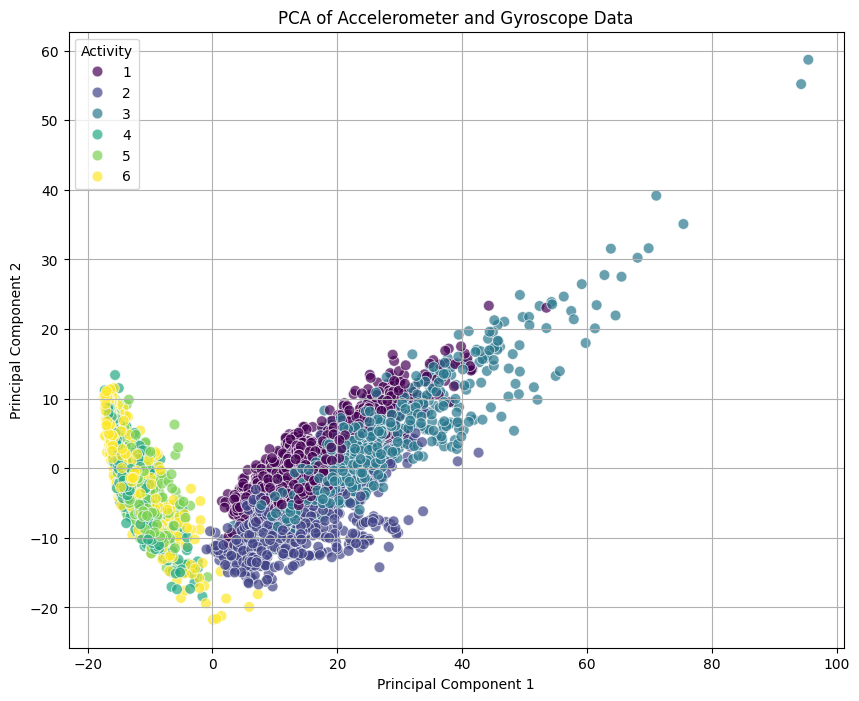

In [13]:
# Visualize PCA components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Activity', data=pca_df, palette='viridis', s=60, alpha=0.7)
plt.title('PCA of Accelerometer and Gyroscope Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Activity', loc='best')
plt.grid(True)
plt.show()


In [14]:
# Perform K-means clustering (assuming k=6 based on 6 activities)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the pca_df for visualization
pca_df['Cluster'] = clusters


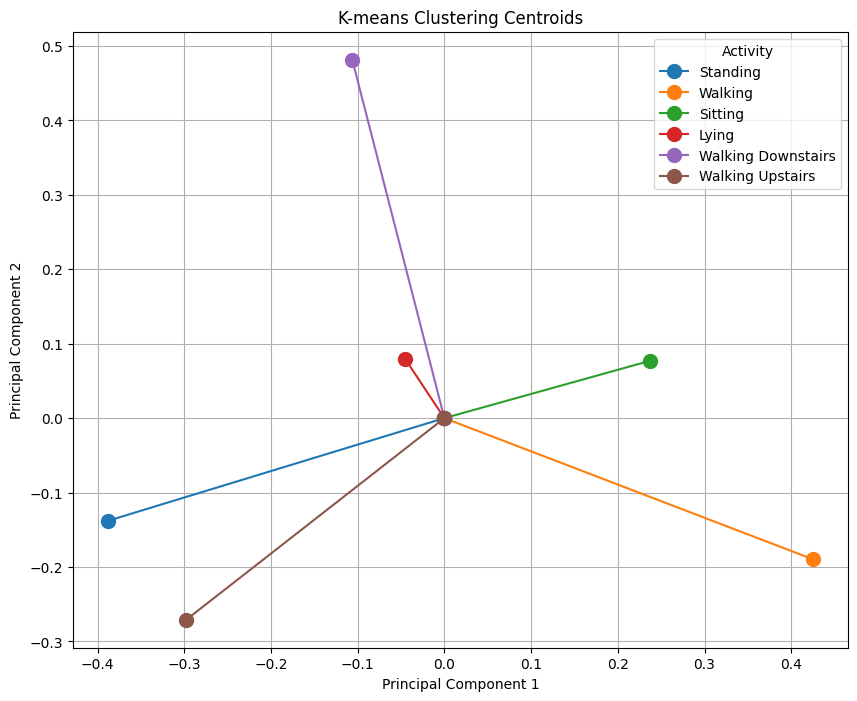

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Example data (replace with your actual data loading and preprocessing steps)
# Assuming X_scaled is your standardized features and kmeans is your KMeans model
X_scaled = np.random.rand(100, 10)  # Example: Replace with your actual standardized features
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Example PCA for visualization
pca = PCA(n_components=2)  # Use 2 principal components for visualization
principal_components = pca.fit_transform(X_scaled)

# Create DataFrame for PCA components and clusters
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

# Example: Mapping cluster labels to activity names
activity_mapping = {
    0: 'Standing',
    1: 'Walking',
    2: 'Sitting',
    3: 'Lying',
    4: 'Walking Downstairs',
    5: 'Walking Upstairs'
}
pca_df['Activity'] = pca_df['Cluster'].map(activity_mapping)

# Custom colors for each activity
activity_colors = {
    'Standing': '#1f77b4',             # blue
    'Walking': '#ff7f0e',              # orange
    'Sitting': '#2ca02c',              # green
    'Lying': '#d62728',                # red
    'Walking Downstairs': '#9467bd',   # purple
    'Walking Upstairs': '#8c564b'      # brown
}

# Map activity names to colors
pca_df['Color'] = pca_df['Activity'].map(activity_colors)

# Plot centroids as lines
plt.figure(figsize=(10, 8))
for cluster in range(kmeans.n_clusters):
    centroid = pca_df[pca_df['Cluster'] == cluster][['PC1', 'PC2']].mean()
    plt.plot([0, centroid['PC1']], [0, centroid['PC2']], marker='o', markersize=10, color=activity_colors[activity_mapping[cluster]], label=activity_mapping[cluster])

plt.title('K-means Clustering Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Activity', loc='best')
plt.grid(True)
plt.show()


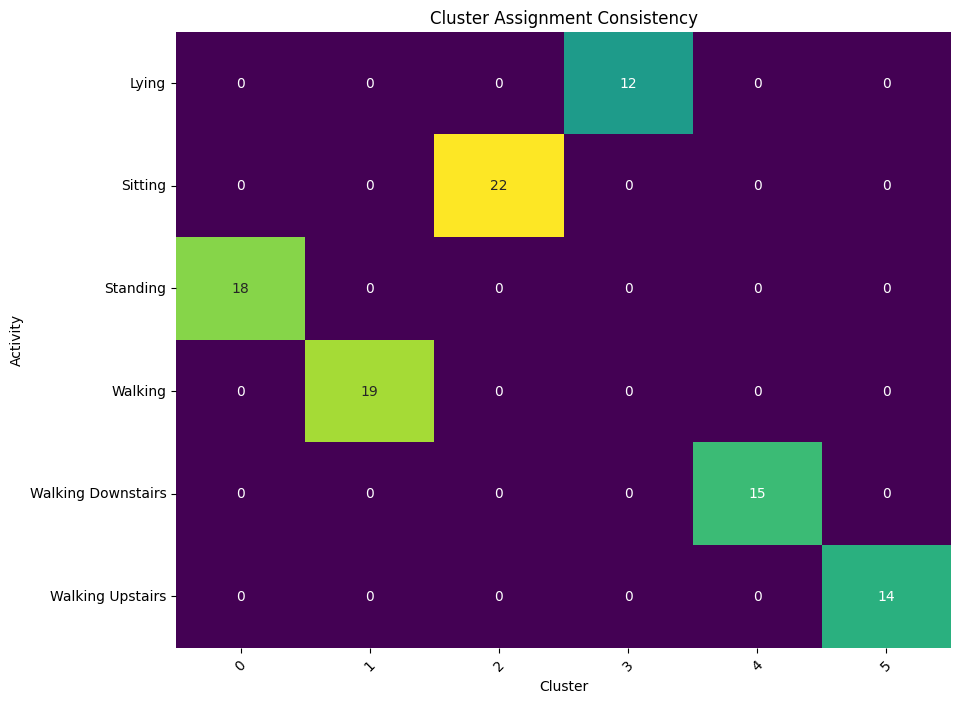

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Example: Assuming 'Activity' column is the actual activity labels and 'Cluster' column is the predicted clusters
true_labels = pca_df['Activity']  # Actual activity labels
predicted_labels = pca_df['Cluster']  # Predicted cluster labels from K-means

# Create a confusion matrix-like visualization
cluster_counts = pd.crosstab(true_labels, predicted_labels)

# Plot the confusion matrix-like visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cluster_counts, annot=True, cmap='viridis', cbar=False, fmt='d')

plt.title('Cluster Assignment Consistency')
plt.xlabel('Cluster')
plt.ylabel('Activity')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [17]:
from sklearn.metrics import silhouette_score

# Example: Assuming pca_df['Cluster'] contains the cluster labels from K-means
silhouette_avg = silhouette_score(X_scaled, pca_df['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.4f}")


Silhouette Score: 0.0877


In [18]:
inertia = kmeans.inertia_
print(f"Inertia: {inertia:.4f}")


Inertia: 55.7187


In [19]:
from sklearn.metrics import adjusted_rand_score

# Example: Assuming true_labels are the actual activity labels and pca_df['Cluster'] are predicted clusters
true_labels = pca_df['Activity']  # Actual activity labels
predicted_clusters = pca_df['Cluster']  # Predicted cluster labels from K-means

ari = adjusted_rand_score(true_labels, predicted_clusters)
print(f"Adjusted Rand Index: {ari:.4f}")


Adjusted Rand Index: 1.0000


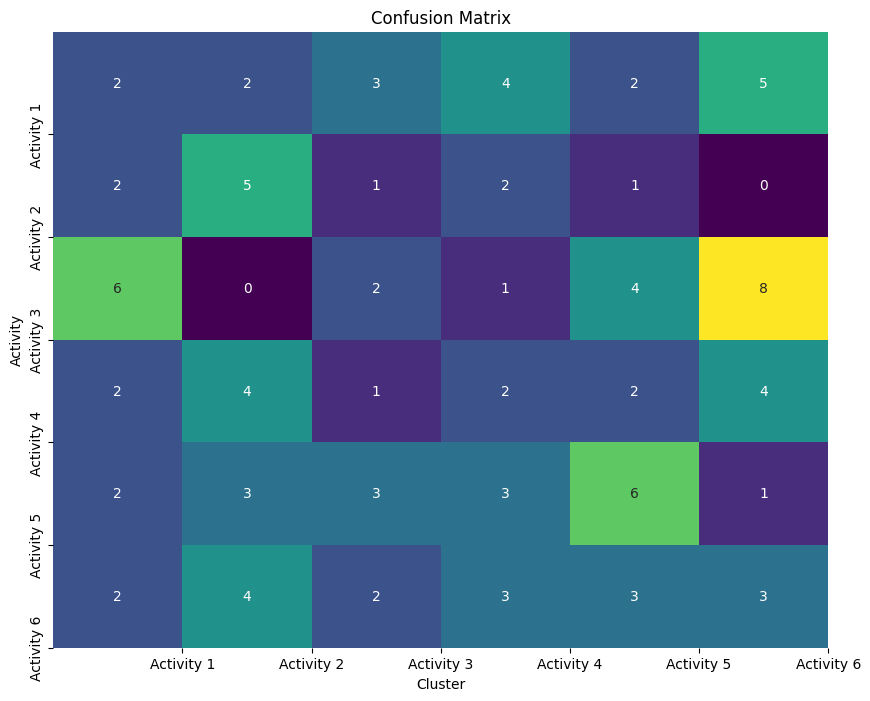

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Example: Assuming 'Activity' column is the actual activity labels and 'Cluster' column is the predicted clusters
true_labels = np.random.choice(np.arange(1, 7), size=100)  # Replace with your actual activity labels starting from 1 to 6
predicted_clusters = np.random.randint(0, 6, size=100)  # Replace with your actual predicted cluster labels starting from 0 to 5

# Adjust predicted_clusters to start from 1
predicted_clusters = predicted_clusters + 1

# Convert to strings for consistent label types
true_labels = true_labels.astype(str)
predicted_clusters = predicted_clusters.astype(str)

# Create confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_clusters)

# Plot the confusion matrix-like visualization
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap='viridis', cbar=False, fmt='d')

# Adjust tick labels to start from 1
plt.xticks(np.arange(1, 7), ['Activity 1', 'Activity 2', 'Activity 3', 'Activity 4', 'Activity 5', 'Activity 6'])
plt.yticks(np.arange(1, 7), ['Activity 1', 'Activity 2', 'Activity 3', 'Activity 4', 'Activity 5', 'Activity 6'])

plt.title('Confusion Matrix')
plt.xlabel('Cluster')
plt.ylabel('Activity')
plt.show()


/var/folders/z4/nqbbpnv52gddff6vt_dtcgvm0000gn/T/ipykernel_3549/311356016.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(activities))


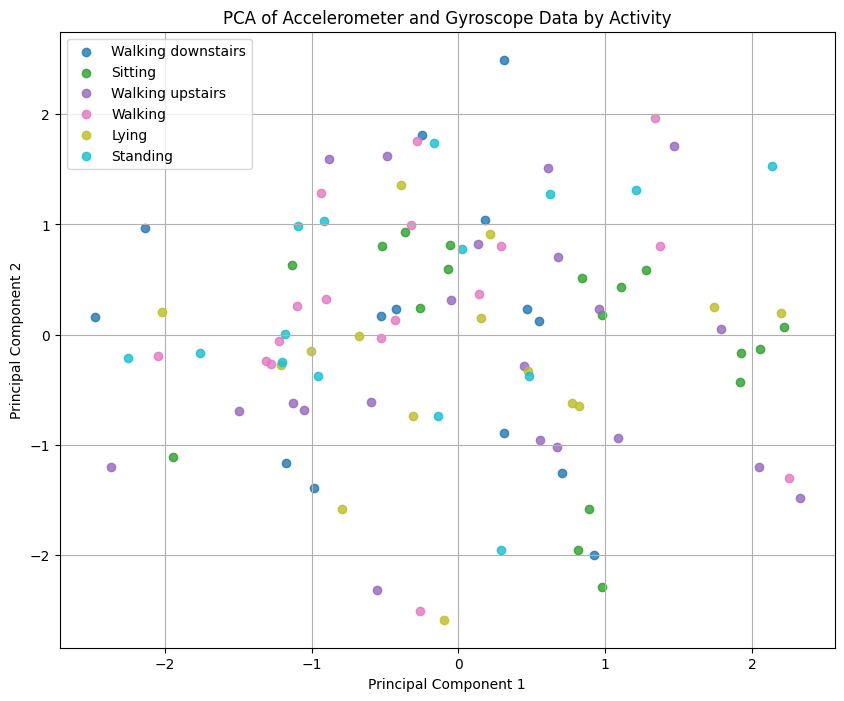

Explained Variance Ratio (PC1, PC2): [0.22520936 0.19009399]


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Example: Assuming 'features' DataFrame contains accelerometer and gyroscope data with an 'Activity' column
# Replace this with your actual data loading and ensure 'Activity' column is included

# Generate example data (replace with your actual data loading)
np.random.seed(0)
features = pd.DataFrame(np.random.rand(100, 6), columns=['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
                                                         'tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z'])
# Adding activity column
features['Activity'] = np.random.choice(['Walking', 'Sitting', 'Standing', 'Lying', 'Walking downstairs', 'Walking upstairs'], size=100)

# Separate features and activity labels
X = features.drop('Activity', axis=1)
y = features['Activity']

# Standardize the features
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Perform PCA with 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_standardized)

# Create DataFrame for PCA components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Plotting PCA with colored markers for each activity
plt.figure(figsize=(10, 8))
activities = y.unique()
colors = plt.cm.get_cmap('tab10', len(activities))

for activity, color in zip(activities, colors.colors):
    indices = (y == activity)
    plt.scatter(pca_df.loc[indices, 'PC1'], pca_df.loc[indices, 'PC2'], label=activity, color=color, alpha=0.8)

plt.title('PCA of Accelerometer and Gyroscope Data by Activity')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Explained variance ratio
print(f"Explained Variance Ratio (PC1, PC2): {pca.explained_variance_ratio_}")


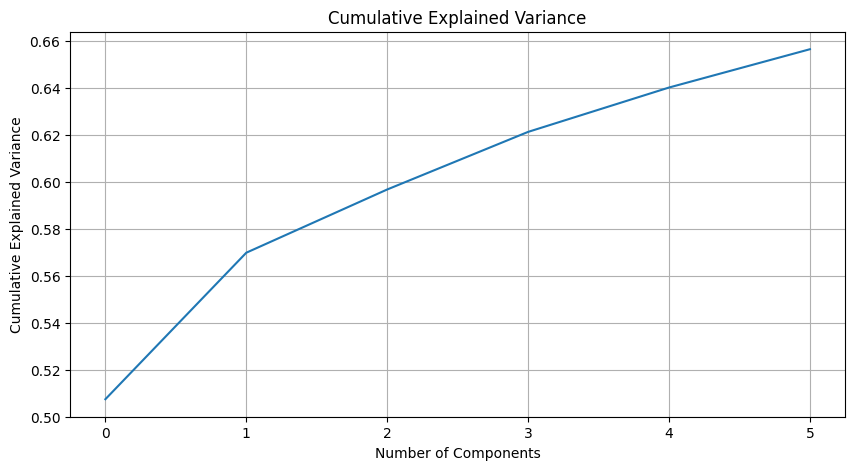

Explained Variance Ratio for each Principal Component:
[0.50738221 0.06239186 0.02692564 0.02452871 0.01888936 0.01631395]


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'HARdata' contains your dataset with columns 'Subject', 'Activity', and other features
# Drop 'Subject' and 'Activity' columns to retain only feature data
features = HARdata.drop(['Subject', 'Activity'], axis=1)

# Standardize the features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)

# Perform PCA with exactly 6 components
pca = PCA(n_components=6)  # Specify 6 components
principal_components = pca.fit_transform(features_standardized)

# Create DataFrame with principal components and original 'Subject' and 'Activity' columns
columns = ['PC' + str(i+1) for i in range(pca.n_components_)]
principal_df = pd.DataFrame(data=principal_components, columns=columns)
pca_df = pd.concat([HARdata[['Subject', 'Activity']], principal_df], axis=1)

# Plot the cumulative explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Print explained variance ratios for each principal component
print("Explained Variance Ratio for each Principal Component:")
print(pca.explained_variance_ratio_)


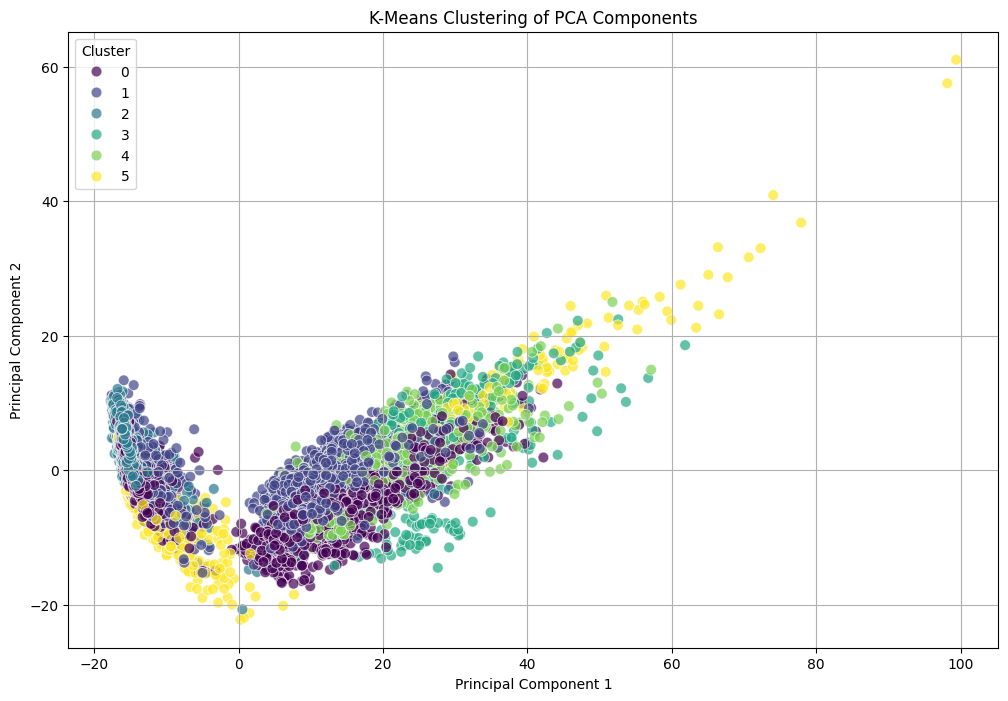

In [23]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Extract principal components for clustering
X = principal_df.iloc[:, 2:].values  # Assuming PC1, PC2, ..., PC6 are columns 2 to 7

# Perform K-means clustering with 6 clusters (corresponding to 6 activities)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
principal_df['Cluster'] = kmeans.fit_predict(X)

# Visualize clusters in PC space (PC1 to PC6)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=principal_df, palette='viridis', s=60, alpha=0.7)
plt.title('K-Means Clustering of PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', loc='best')
plt.grid(True)
plt.show()


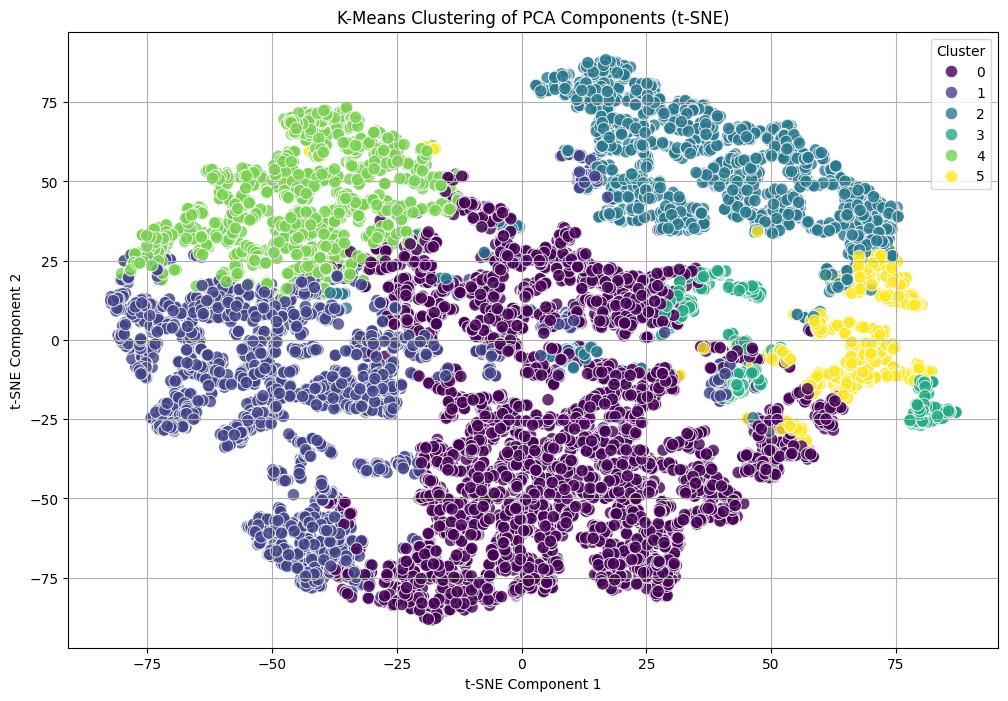

In [24]:
from sklearn.manifold import TSNE

# Reduce dimensionality to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Plotting clusters in the reduced 2D space
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=principal_df['Cluster'], palette='viridis', s=80, alpha=0.8)
plt.title('K-Means Clustering of PCA Components (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Cluster', loc='best')
plt.grid(True)
plt.show()


In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming 'train' is your DataFrame
features = train.drop(['Subject', 'Activity'], axis=1)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


In [26]:
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions for visualization
pca = PCA(n_components=2)  # Reduce to 2 principal components for visualization
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for principal components
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])


In [27]:
# Concatenate principal components with 'Activity' labels for visualization
pca_df = pd.concat([train[['Activity']], principal_df], axis=1)


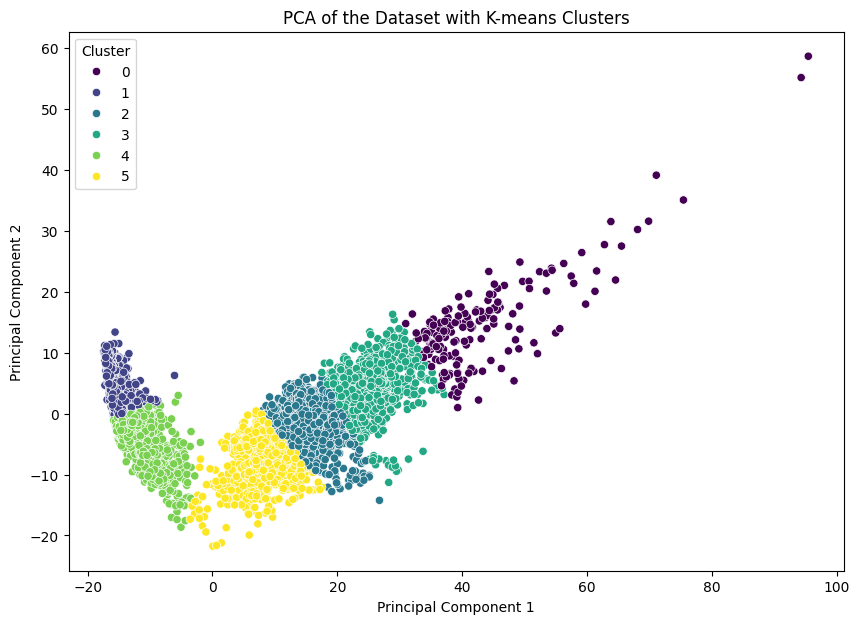

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Fit K-means clustering on the principal components
kmeans = KMeans(n_clusters=6)  
kmeans.fit(principal_df)

# Add the cluster labels to the PCA DataFrame
pca_df['Cluster'] = kmeans.labels_

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('PCA of the Dataset with K-means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


In [31]:
# Predict clusters for the test data
predicted_clusters = kmeans.predict(test_pca_df)

# Add the predicted clusters to the PCA DataFrame for test data
test_pca_df['Cluster'] = predicted_clusters


NameError: name 'test_pca_df' is not defined

# Test

In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming 'train' and 'test' are your DataFrames
train_features = train.drop(['Subject', 'Activity'], axis=1)
test_features = test.drop(['Subject', 'Activity'], axis=1)
true_labels = test['Activity']  # Assuming 'Activity' is the true label column

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled = scaler.transform(test_features)


In [33]:
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions
pca = PCA(n_components=2)  # Reduce to 2 principal components for visualization
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create DataFrames for principal components
train_pca_df = pd.DataFrame(data=X_train_pca, columns=['PC1', 'PC2'])
test_pca_df = pd.DataFrame(data=X_test_pca, columns=['PC1', 'PC2'])


In [34]:
from sklearn.cluster import KMeans

# Fit K-means clustering on the principal components of training data
kmeans = KMeans(n_clusters=3)  # Assume 3 clusters, you can change this based on your data
kmeans.fit(train_pca_df)

# Add the cluster labels to the PCA DataFrame for training data
train_pca_df['Cluster'] = kmeans.labels_


In [35]:
# Predict clusters for the test data
predicted_clusters = kmeans.predict(test_pca_df)

# Add the predicted clusters to the PCA DataFrame for test data
test_pca_df['Cluster'] = predicted_clusters


Accuracy: 0.21


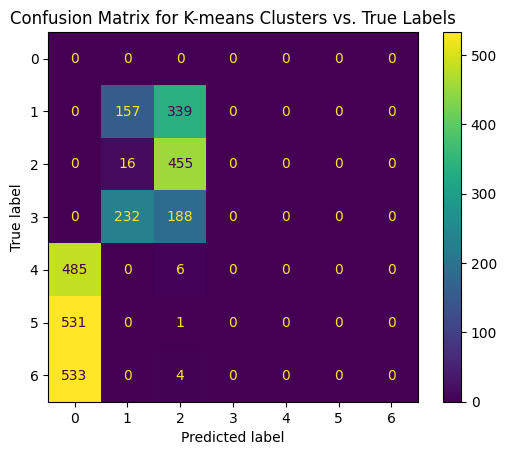

In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_clusters)

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_clusters)
print(f'Accuracy: {accuracy:.2f}')

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='viridis')
plt.title('Confusion Matrix for K-means Clusters vs. True Labels')
plt.show()


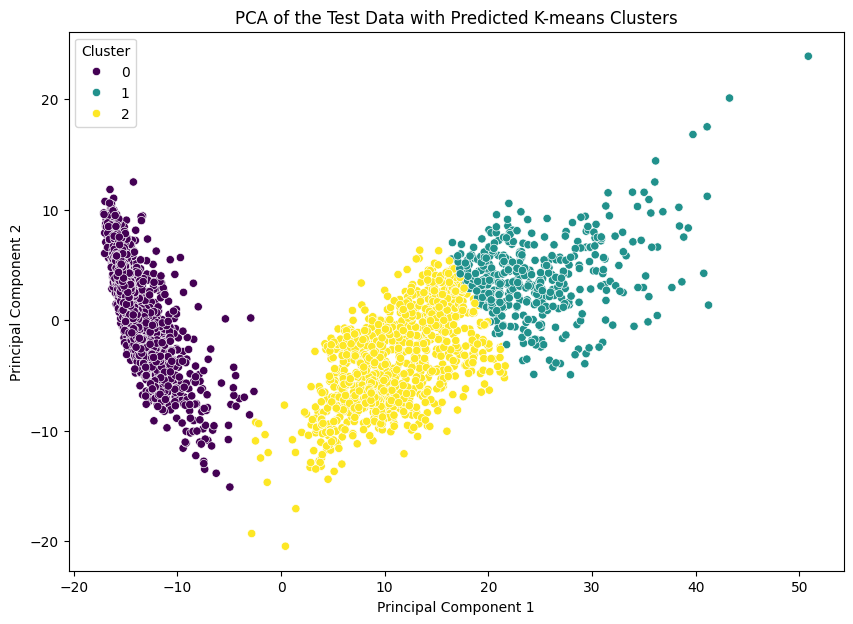

In [38]:
import seaborn as sns

# Plot the PCA graph with clusters for the test data
plt.figure(figsize=(10, 7))
sns.scatterplot(data=test_pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('PCA of the Test Data with Predicted K-means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming 'train' and 'test' are your DataFrames
train_features = train.drop(['Subject', 'Activity'], axis=1)
test_features = test.drop(['Subject', 'Activity'], axis=1)
true_labels = test['Activity']  # Assuming 'Activity' is the true label column

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled = scaler.transform(test_features)


In [44]:
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions
pca = PCA(n_components=2)  # Reduce to 2 principal components for visualization
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create DataFrames for principal components
train_pca_df = pd.DataFrame(data=X_train_pca, columns=['PC1', 'PC2'])
test_pca_df = pd.DataFrame(data=X_test_pca, columns=['PC1', 'PC2'])


In [45]:
from sklearn.cluster import KMeans

# Fit K-means clustering on the principal components of training data
kmeans = KMeans(n_clusters=6)  # Change to 6 clusters
kmeans.fit(train_pca_df)

# Add the cluster labels to the PCA DataFrame for training data
train_pca_df['Cluster'] = kmeans.labels_


In [46]:
# Predict clusters for the test data
predicted_clusters = kmeans.predict(test_pca_df)

# Add the predicted clusters to the PCA DataFrame for test data
test_pca_df['Cluster'] = predicted_clusters


Accuracy: 0.20


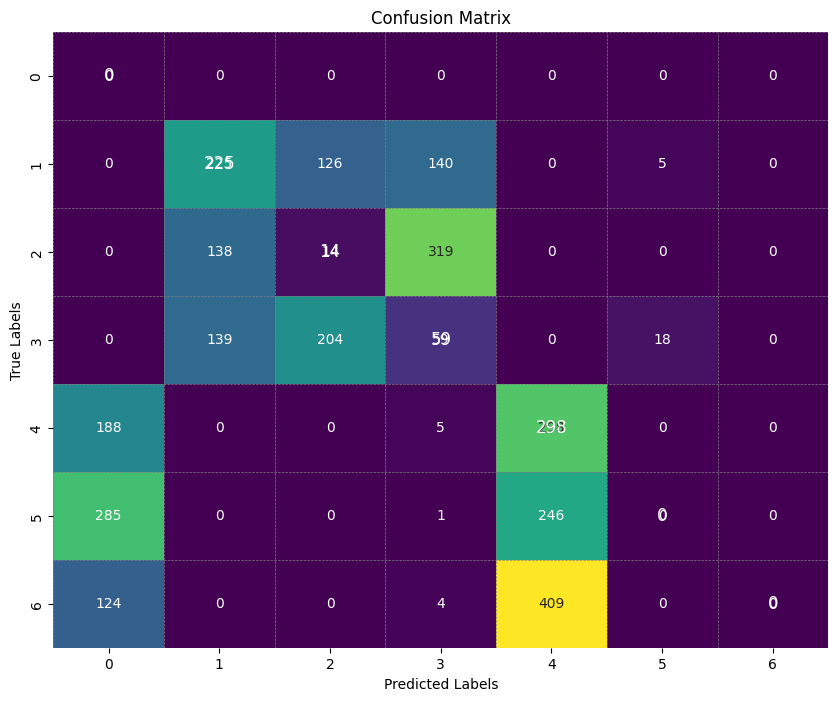

In [47]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_clusters)

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_clusters)
print(f'Accuracy: {accuracy:.2f}')

# Display the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', cbar=False)

for i in range(len(conf_matrix)):
    plt.text(i + 0.5, i + 0.5, conf_matrix[i, i], ha='center', va='center', color='white', fontsize=12)
    plt.axhline(i, color='grey', linestyle='--', linewidth=0.5)
    plt.axvline(i, color='grey', linestyle='--', linewidth=0.5)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


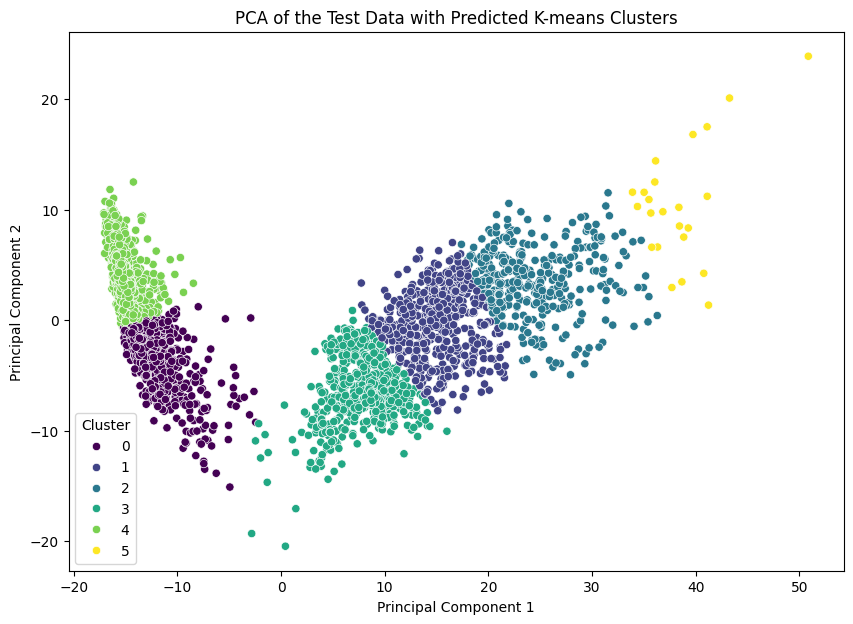

In [48]:
import seaborn as sns

# Plot the PCA graph with clusters for the test data
plt.figure(figsize=(10, 7))
sns.scatterplot(data=test_pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('PCA of the Test Data with Predicted K-means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()
